<a href="https://colab.research.google.com/github/Aleska134/AI-Projects/blob/main/04-Data-Wrangling/Non-Guided-Project/NG04_Public_Health_Data_Prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Non-Guided Project 4: Public Health Data Preparation
## Chapter 4: Data Wrangling and Preparation

**AI Thinking: A Hands-On Introduction to Artificial Intelligence**

---

### Scenario

You're volunteering with a community health nonprofit in Miami-Dade County. They've been collecting data on patient visits across several neighborhood clinics, but the data has quality issues. Before the nonprofit can present findings to the county health board, the data needs to be cleaned and summarized.

Your job: **Clean this dataset and prepare a summary of key findings.**

---

### What You'll Practice
- Loading and exploring a dataset
- Finding and handling missing values
- Removing duplicates
- Standardizing inconsistent text
- Filtering out invalid data
- Basic analysis using groupby and value_counts

### Dataset Columns
| Column | Description |
|--------|-------------|
| visit_id | Unique ID for each visit |
| zip_code | Clinic zip code |
| neighborhood | Clinic neighborhood |
| visit_type | Type of visit (e.g., Flu Vaccination, Dental Cleaning) |
| age_group | Patient age range |
| gender | Patient gender |
| insurance_type | Insurance category |
| preferred_language | Patient's preferred language |
| wait_time_minutes | How long the patient waited |
| satisfaction_score | Patient satisfaction (1-5 scale) |
| follow_up_needed | Whether a follow-up visit is needed (Yes/No) |

---
## Part 1: Load and Explore the Data

Import pandas, load the CSV file, and explore the dataset using the methods from the guided project:
- `.head()`
- `.shape`
- `.info()`
- `.describe()`

In [46]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv('community_health_visits.csv')

# View the first few rows
df.head()

,visit_id,zip_code,neighborhood,visit_type,age_group,gender,insurance_type,preferred_language,wait_time_minutes,satisfaction_score,follow_up_needed
0,5030,33132,Downtown Miami,COVID Vaccination,26-35,Non-Binary,PRIVATE,Spanish,60.0,5.0,Yes
1,5065,33139,Miami Beach,MENTAL HEALTH CONSULTATION,26-35,Male,Uninsured,Spanish,79.0,3.0,Yes
2,5064,33145,Coral Way,Vision Screening,18-25,Male,Medicare,English,90.0,1.0,Yes
3,5053,33132,Downtown Miami,Diabetes Screening,65+,Male,uninsured,Spanish,55.0,2.0,No
4,5045,33130,Brickell,Dental Cleaning,26-35,Male,Private,English,480.0,3.0,Yes


In [47]:
# Check the shape of the dataset
# YOUR CODE HERE
df.shape
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 104 rows and 11 columns.


In [48]:
# Run .info() to see column types and non-null counts
# YOUR CODE HERE
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visit_id            104 non-null    int64  
 1   zip_code            104 non-null    int64  
 2   neighborhood        98 non-null     object 
 3   visit_type          104 non-null    object 
 4   age_group           104 non-null    object 
 5   gender              104 non-null    object 
 6   insurance_type      99 non-null     object 
 7   preferred_language  101 non-null    object 
 8   wait_time_minutes   100 non-null    float64
 9   satisfaction_score  94 non-null     float64
 10  follow_up_needed    104 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 9.1+ KB


In [49]:
# Run .describe() to see statistics for numerical columns
# YOUR CODE HERE
df.describe()

,visit_id,zip_code,wait_time_minutes,satisfaction_score
count,104.000000,104.000000,100.000000,94.000000
mean,5049.221154,33099.230769,52.050000,3.680851
std,28.972688,57.941757,50.366811,1.415830
min,5000.000000,33010.000000,-15.000000,0.000000
25%,5024.750000,33012.000000,23.750000,3.000000
50%,5049.500000,33132.000000,54.000000,4.000000
75%,5074.250000,33139.000000,66.000000,5.000000
max,5099.000000,33155.000000,480.000000,8.000000


### ✏️ Your Observations

Before moving on, write down what you notice. Double-click this cell to edit.

- How many rows and columns does the dataset have?
- Which columns appear to have missing values?
- Do any of the min/max values in `.describe()` look suspicious?
- Anything else that looks off?

*Your notes:*
Min wait time is negative.
Satisfaction score values max and min are wrong (1-5 scale).



---
## Part 2: Find Missing Values

Count the missing values in each column. Then calculate the percentage of missing values.

**Hint:** You did this in the guided project with `.isnull().sum()`

In [50]:
# Count missing values per column
# YOUR CODE HERE
print(df.isnull().sum())


visit_id               0
zip_code               0
neighborhood           6
visit_type             0
age_group              0
gender                 0
insurance_type         5
preferred_language     3
wait_time_minutes      4
satisfaction_score    10
follow_up_needed       0
dtype: int64


In [51]:
# Calculate missing value percentages
# Hint: (df.isnull().sum() / len(df) * 100).round(1)
# YOUR CODE HERE

missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
print("\nMissing value percentages:")
print(missing_pct)


Missing value percentages:
visit_id              0.0
zip_code              0.0
neighborhood          5.8
visit_type            0.0
age_group             0.0
gender                0.0
insurance_type        4.8
preferred_language    2.9
wait_time_minutes     3.8
satisfaction_score    9.6
follow_up_needed      0.0
dtype: float64


---
## Part 3: Handle Missing Values

Decide how to handle each column with missing data. Here's a guide:

| Column | Suggested Strategy |
|--------|-------------------|
| neighborhood | Fill with `'Unknown'` |
| insurance_type | Fill with `'Unknown'` |
| preferred_language | Fill with `'Unknown'` |
| wait_time_minutes | Fill with the **median** |
| satisfaction_score | Fill with the **median** |

Use `.fillna()` for each column.

In [52]:
# Fill missing text columns with 'Unknown'
# YOUR CODE HERE

df['neighborhood'] = df['neighborhood'].fillna('Unknown')
df['insurance_type'] = df['insurance_type'].fillna('Unknown')
df['preferred_language'] = df['preferred_language'].fillna('Unknown')



In [53]:
# Fill missing numerical columns with the median
# YOUR CODE HERE
# Convert 'wait_time_minutes' to numeric, coercing errors to NaN, then fill with median
df['wait_time_minutes'] = pd.to_numeric(df['wait_time_minutes'], errors='coerce')
median_wait_time_minutes = df['wait_time_minutes'].median()
print(f"Median wait_time_minutes: {median_wait_time_minutes:.2f}")
df['wait_time_minutes'] = df['wait_time_minutes'].fillna(median_wait_time_minutes)

# Convert 'satisfaction_score' to numeric, coercing errors to NaN, then fill with median
df['satisfaction_score'] = pd.to_numeric(df['satisfaction_score'], errors='coerce')
median_satisfaction_score = df['satisfaction_score'].median()
print(f"Median satisfaction_score: {median_satisfaction_score:.2f}")
df['satisfaction_score'] = df['satisfaction_score'].fillna(median_satisfaction_score)


Median wait_time_minutes: 54.00
Median satisfaction_score: 4.00


In [54]:
# Verify: check that no missing values remain
# YOUR CODE HERE
print("Missing values after cleanup:")
print(df.isnull().sum())


Missing values after cleanup:
visit_id              0
zip_code              0
neighborhood          0
visit_type            0
age_group             0
gender                0
insurance_type        0
preferred_language    0
wait_time_minutes     0
satisfaction_score    0
follow_up_needed      0
dtype: int64


---
## Part 4: Remove Duplicates

Check for and remove any duplicate rows.

**Hint:** `.duplicated().sum()` and `.drop_duplicates()`

In [55]:
# Check for duplicates, print the count, then remove them
# Print row count before and after
# YOUR CODE HERE
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Number of rows after dropping duplicates: {df.shape[0]}")

Number of duplicate rows: 4
Number of rows after dropping duplicates: 100


---
## Part 5: Standardize Text

Several text columns have inconsistent formatting (mixed uppercase/lowercase, extra spaces). Standardize the following columns:

- `visit_type`
- `neighborhood`
- `insurance_type`
- `follow_up_needed`

**Hint:** Use `.str.lower().str.strip()` on each column.

Check the unique values **before** and **after** cleaning to confirm it worked.

In [56]:
# Check unique values BEFORE cleaning
print("visit_type values:")
print(df['visit_type'].unique())
print(f"\nCount: {df['visit_type'].nunique()} unique values")

visit_type values:
['COVID Vaccination' 'MENTAL HEALTH CONSULTATION' 'Vision Screening'
 'Diabetes Screening' 'Dental Cleaning' 'Annual Checkup' 'FLU VACCINATION'
 'Mental Health Consultation' 'Flu Vaccination' 'Blood Pressure Screening'
 'annual checkup' 'diabetes screening ' 'COVID vaccination'
 ' Blood Pressure Screening' ' dental cleaning']

Count: 15 unique values


In [57]:
# Standardize all four text columns
# YOUR CODE HERE
df['visit_type'] = df['visit_type'].str.lower().str.strip()
df['neighborhood'] = df['neighborhood'].str.lower().str.strip()
df['insurance_type'] = df['insurance_type'].str.lower().str.strip()
df['follow_up_needed'] = df['follow_up_needed'].str.lower().str.strip()

In [58]:
# Check unique values AFTER cleaning
print("visit_type values:")
print(df['visit_type'].unique())
print(f"\nCount: {df['visit_type'].nunique()} unique values")

visit_type values:
['covid vaccination' 'mental health consultation' 'vision screening'
 'diabetes screening' 'dental cleaning' 'annual checkup' 'flu vaccination'
 'blood pressure screening']

Count: 8 unique values


In [59]:
# Also check the other columns you cleaned
# YOUR CODE HERE
print("neighborhood values:")
print(df['neighborhood'].unique())
print(f"\nCount: {df['neighborhood'].nunique()} unique values")

print("\ninsurance_type values:")
print(df['insurance_type'].unique())

print("\nfollow_up_needed values:")
print(df['follow_up_needed'].unique())

neighborhood values:
['downtown miami' 'miami beach' 'coral way' 'brickell' 'hialeah gardens'
 'flagami' 'unknown' 'liberty city' 'westchester' 'hialeah'
 'little havana']

Count: 11 unique values

insurance_type values:
['private' 'uninsured' 'medicare' 'medicaid' 'unknown']

follow_up_needed values:
['yes' 'no']


---
## Part 6: Filter Out Bad Data

Check for values that don't make sense:

1. **Negative wait times** — wait_time_minutes should be positive
2. **Invalid satisfaction scores** — should be between 1 and 5
3. **Unreasonable wait times** — anything over 180 minutes (3 hours) is likely an error

First, **find** the bad rows. Then **filter** them out.

In [60]:
# Find rows with negative wait times
# YOUR CODE HERE
bad_wait_times = df[df['wait_time_minutes'] < 0]
print(bad_wait_times)


    visit_id  zip_code neighborhood          visit_type age_group  gender  \
37      5062     33139  miami beach  diabetes screening     46-55  Female   
97      5020     33145    coral way      annual checkup     56-65  Female   

   insurance_type preferred_language  wait_time_minutes  satisfaction_score  \
37      uninsured            English               -5.0                 4.0   
97        private            Spanish              -15.0                 3.0   

   follow_up_needed  
37               no  
97               no  


In [61]:
# Find rows with invalid satisfaction scores (outside 1-5)
# YOUR CODE HERE
invalid_satisfaction = df[(df['satisfaction_score'] < 1) | (df['satisfaction_score'] > 5)]
print(invalid_satisfaction)

    visit_id  zip_code    neighborhood          visit_type age_group gender  \
85      5037     33139     miami beach  diabetes screening     26-35   Male   
92      5087     33132  downtown miami    vision screening     18-25   Male   

   insurance_type preferred_language  wait_time_minutes  satisfaction_score  \
85        private         Portuguese               66.0                 8.0   
92       medicare            Spanish               24.0                 0.0   

   follow_up_needed  
85              yes  
92               no  


In [62]:
# Find rows with unreasonable wait times (over 180 minutes)
# YOUR CODE HERE
unreasonable_wait_times = df[df['wait_time_minutes'] > 180]
print(unreasonable_wait_times)

   visit_id  zip_code neighborhood       visit_type age_group gender  \
4      5045     33130     brickell  dental cleaning     26-35   Male   

  insurance_type preferred_language  wait_time_minutes  satisfaction_score  \
4        private            English              480.0                 3.0   

  follow_up_needed  
4              yes  


In [63]:
# Remove all bad data
# Print row count before and after
# YOUR CODE HERE

print(f"Rows before filtering: {len(df)}")

# Define conditions for VALID data
valid_wait_time = (df['wait_time_minutes'] >= 0) & (df['wait_time_minutes'] <= 180)
valid_satisfaction_score = (df['satisfaction_score'] >= 1) & (df['satisfaction_score'] <= 5)

# Combine all valid conditions and filter the DataFrame
df = df[valid_wait_time & valid_satisfaction_score]

print(f"Rows after filtering: {len(df)}")

Rows before filtering: 100
Rows after filtering: 95


---
## Part 7: Verify Your Clean Data

Print a final summary confirming the data is clean:
- Total rows and columns
- Total missing values (should be 0)
- Total duplicates (should be 0)
- Value ranges for wait_time_minutes and satisfaction_score

In [64]:
# Print your clean data summary
# YOUR CODE HERE
print("=== CLEAN DATA SUMMARY ===")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Total duplicates: {df.duplicated().sum()}")
print(f"Value range for wait time: min: {df['wait_time_minutes'].min()}, max: {df['wait_time_minutes'].max()}")
print(f"Value range for satisfaction score: min: {df['satisfaction_score'].min()}, max: {df['satisfaction_score'].max()}")

=== CLEAN DATA SUMMARY ===
Total rows: 95
Total columns: 11
Total missing values: 0
Total duplicates: 0
Value range for wait time: min: 6.0, max: 90.0
Value range for satisfaction score: min: 1.0, max: 5.0


---
## Part 8: Analyze the Clean Data

Now answer these questions using the clean data. Use `.groupby()`, `.value_counts()`, and `.mean()` as needed.

**Question 1:** What are the most common visit types?

In [65]:
# Most common visit types
# YOUR CODE HERE

print("Most common visit types:")
print(df['visit_type'].value_counts())

Most common visit types:
visit_type
annual checkup                16
vision screening              14
diabetes screening            13
dental cleaning               12
flu vaccination               11
covid vaccination             11
mental health consultation    10
blood pressure screening       8
Name: count, dtype: int64


**Question 2:** What is the average wait time by neighborhood?

In [66]:
# Average wait time by neighborhood
# YOUR CODE HERE
print("Average wait time by neighborhood:")
print(df.groupby('neighborhood')['wait_time_minutes'].mean().round(2))

Average wait time by neighborhood:
neighborhood
brickell           42.50
coral way          37.33
downtown miami     46.60
flagami            56.17
hialeah            42.17
hialeah gardens    48.47
liberty city       52.64
little havana      49.50
miami beach        52.50
unknown            64.83
westchester        61.00
Name: wait_time_minutes, dtype: float64


**Question 3:** What is the average satisfaction score by insurance type?

In [67]:
# Average satisfaction by insurance type
# YOUR CODE HERE
print("Average satisfaction by insurance type:")
print(df.groupby('insurance_type')['satisfaction_score'].mean().round(2))

Average satisfaction by insurance type:
insurance_type
medicaid     4.04
medicare     3.36
private      3.73
uninsured    3.89
unknown      3.40
Name: satisfaction_score, dtype: float64


**Question 4:** What percentage of visits require a follow-up?

In [68]:
# Follow-up percentage
# Hint: use .value_counts() on follow_up_needed
# YOUR CODE HERE
average_follow_up = (df['follow_up_needed'].value_counts(normalize=True) * 100).round(1)
print("Percentage of visits requiring a follow-up:")
print(average_follow_up)


Percentage of visits requiring a follow-up:
follow_up_needed
yes    51.6
no     48.4
Name: proportion, dtype: float64


**Question 5:** What is the most common preferred language across all visits?

In [69]:
# Preferred language breakdown
# YOUR CODE HERE
print("Preferred language breakdown:")
print(df['preferred_language'].value_counts())

Preferred language breakdown:
preferred_language
Spanish       37
English       33
Portuguese    13
Creole         9
Unknown        3
Name: count, dtype: int64


---
## Part 9: Create a Visualization

Create **at least one** chart from your analysis. Pick whichever question you find most interesting.

**Hint:**
```python
import matplotlib.pyplot as plt

# Example: bar chart
your_data.plot(kind='bar')  # or 'barh' for horizontal
plt.title('Your Title')
plt.xlabel('X Label')
plt.ylabel('Y Label')
plt.tight_layout()
plt.show()
```

Text(0, 0.5, 'Average Wait Time (minutes)')

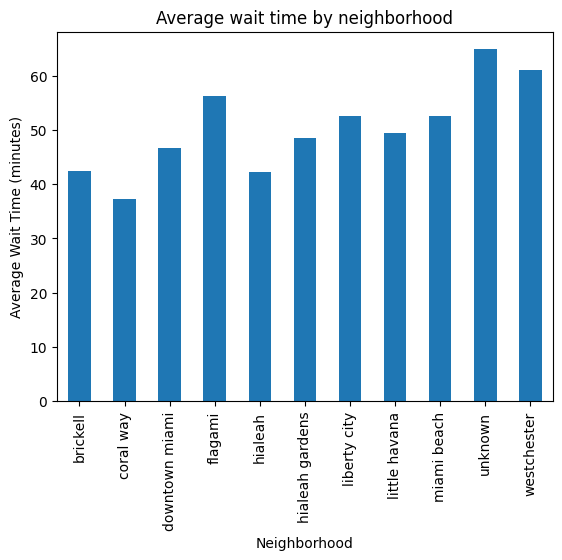

In [70]:
import matplotlib.pyplot as plt

# Create your visualization
# YOUR CODE HERE
df.groupby('neighborhood')['wait_time_minutes'].mean().plot(kind='bar')
plt.title('Average wait time by neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average Wait Time (minutes)')

---
## Part 10: Reflection

Double-click this cell and answer the following questions:

**1. What was the messiest part of this dataset? How did you fix it?**

*Your answer:
The messiest part of this dataset involved the wait_time_minutes and satisfaction_score columns.  Wait_time_minutes contained negative and unrealistically high values, while satisfaction_score had entries outside its expected 1-5 range. These issues were fixed by first handling missing values with the median, then filtering out all rows where wait_time_minutes was negative or exceeded 180 minutes, and where satisfaction_score was outside the valid 1-5 range.

**2. Were there any decisions you had to make about how to handle the data (e.g., what to do with missing values, which rows to remove)? Explain your reasoning.**

*Your answer: Yes, I had to make some choices about how to clean the data. When some text information was missing (like 'neighborhood'), I filled it with 'Unknown' so I didn't lose the whole patient record. For numbers that were missing (like 'wait time' or 'satisfaction score'), I used the 'median' value to fill them in. I picked the median because it's good at ignoring really weird or extreme numbers that could mess up my average. I also removed any rows where the 'wait time' was negative or extremely long (over 180 minutes), or where the 'satisfaction score' was outside its normal range of 1 to 5. I did this because those numbers just didn't make sense and would have made my results wrong.


**3. What was one interesting finding from your analysis of the clean data?**

*Your answer: One interesting finding from my analysis was the significant variation in average wait times across different neighborhoods. For instance, the 'Unknown' and 'Westchester' neighborhoods showed the highest average wait times, while 'Brickell' and 'Coral Way' had the lowest. This suggests potential differences in clinic efficiency or demand in these areas.



---
## ✅ Submission Checklist

Before submitting, make sure you have:

- [ ] Loaded and explored the data (Part 1)
- [ ] Identified all missing values (Part 2)
- [ ] Handled all missing values (Part 3)
- [ ] Removed duplicate rows (Part 4)
- [ ] Standardized text in at least 4 columns (Part 5)
- [ ] Filtered out invalid data (Part 6)
- [ ] Verified the clean dataset (Part 7)
- [ ] Answered all 5 analysis questions (Part 8)
- [ ] Created at least one visualization (Part 9)
- [ ] Completed the reflection (Part 10)

**Save your notebook and submit!**